## Importing libraries

In [404]:
# lets import the libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [405]:
# lets just import the data
df= pd.read_csv("data.csv")


## EDA

In [406]:
# lets check the basic description of the data
df

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53040,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53041,"selfishness ""I don't feel very good, it's lik...",Anxiety
53042,Is there any way to sleep better? I can't slee...,Anxiety
53043,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [407]:
# lets do basic preprocessing 
# check null values
df.isna().sum()


statement    364
status         3
dtype: int64

In [408]:
# lets drop them
df.dropna(inplace=True)

In [409]:
df.reset_index()

,index,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
52675,53040,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
52676,53041,"selfishness ""I don't feel very good, it's lik...",Anxiety
52677,53042,Is there any way to sleep better? I can't slee...,Anxiety
52678,53043,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [410]:
# lets check for null duplicate values
print(f"duplicated counts is {df.duplicated().sum()}")
df[df.duplicated()]

duplicated counts is 1592


,statement,status
97,"""No regrets or grudges/angry at things that ha...",Anxiety
138,but my heart is still restless even though my ...,Anxiety
167,I want to exhale the restlessness in my chest ...,Anxiety
228,Do not compare yourself to others. Envy only m...,Anxiety
244,"people seem calm, happy like there's no proble...",Anxiety
...,...,...
53040,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53041,"selfishness ""I don't feel very good, it's lik...",Anxiety
53042,Is there any way to sleep better? I can't slee...,Anxiety
53043,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [411]:
# i think this is not duplicated data 

                 status  statement
0  Personality disorder       1077
1                Stress       2587
2               Bipolar       2777
3               Anxiety       3841
4              Suicidal      10651
5            Depression      15404
6                Normal      16343


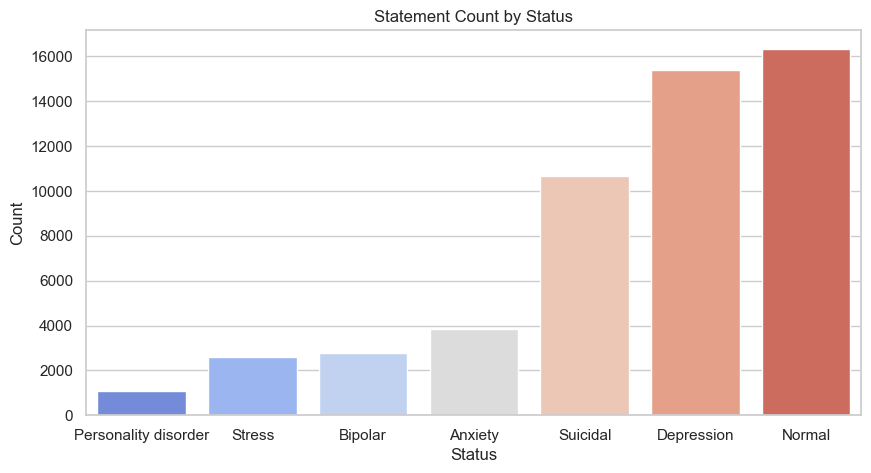

In [412]:
# lets undersatnd the class distribution of data
data = df.groupby('status')['statement'].count().sort_values().reset_index()
print(data)

plt.figure(figsize=(10,5))
sns.barplot(data=data, x='status', y='statement',palette="coolwarm")
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Statement Count by Status')
plt.show()

In [413]:
df.describe()

,statement,status
count,52680,52680
unique,51068,7
top,what do you mean?,Normal
freq,22,16343


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52680 entries, 0 to 53044
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52680 non-null  object
 1   status     52680 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [415]:
df.shape

(52680, 2)

In [416]:
# lets now make some more feature which help to undertand the data
df['statement_length'] = df['statement'].apply(len)
df['num_words'] = df['statement'].apply(lambda x: len(x.split()))
df.head()

,statement,status,statement_length,num_words
0,oh my gosh,Anxiety,10,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14
3,I've shifted my focus to something else but I'...,Anxiety,61,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14


In [417]:
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(x.split())))

In [418]:
df['avg_word_length'] = np.round(df['statement_length'] / df['num_words'])
df['avg_word_length'] = df['avg_word_length'].map(int)

In [419]:
# now lets undertsand the relation with the category 
num_feature = df.select_dtypes(include=np.number).columns
num_feature

Index(['statement_length', 'num_words', 'vocabulary_size', 'avg_word_length'], dtype='object')

In [420]:
df.groupby("status")[['statement_length', 'num_words', 'vocabulary_size', 'avg_word_length']].agg(["mean","median","std"]).reset_index()

status statement_length                       num_words  \
                                    mean median          std        mean   
0               Anxiety       764.681073  544.0   812.378061  143.837022   
1               Bipolar       946.074901  699.0   952.510895  176.200216   
2            Depression       844.014996  562.0   953.016303  168.018177   
3                Normal        90.235942   50.0   120.899736   17.244692   
4  Personality disorder       956.731662  736.0  1149.828710  179.346332   
5                Stress       613.545419  459.0   570.071569  114.585234   
6              Suicidal       731.913905  453.0   931.976663  145.854474   

                     vocabulary_size                   avg_word_length         \
  median         std            mean median        std            mean median   
0  102.0  152.625874       92.598282   76.0  78.685220        5.324915    5.0   
1  129.0  176.488767      112.727764   93.0  82.582965        5.352899    5.0   
2  113.0  188.235576       96.838484   77.0  79.933838        5.096014    5.0   
3   10.0   22.769283       15.027412    9.0  16.969733        5.293826    5.0   
4  137.0  221.891522      109.750232   95.0  83.835927        5.471681    5.0   
5   87.0  105.895609       78.997681   66.0  53.523000        5.545419    5.0   
6   92.0  177.213461       86.041405   64.0  78.130617        5.339593    5.0   

              
         std  
0   0.687027  
1   0.574481  
2   2.412784  
3   1.633974  
4   1.121100  
5   1.996654  
6  30.620305

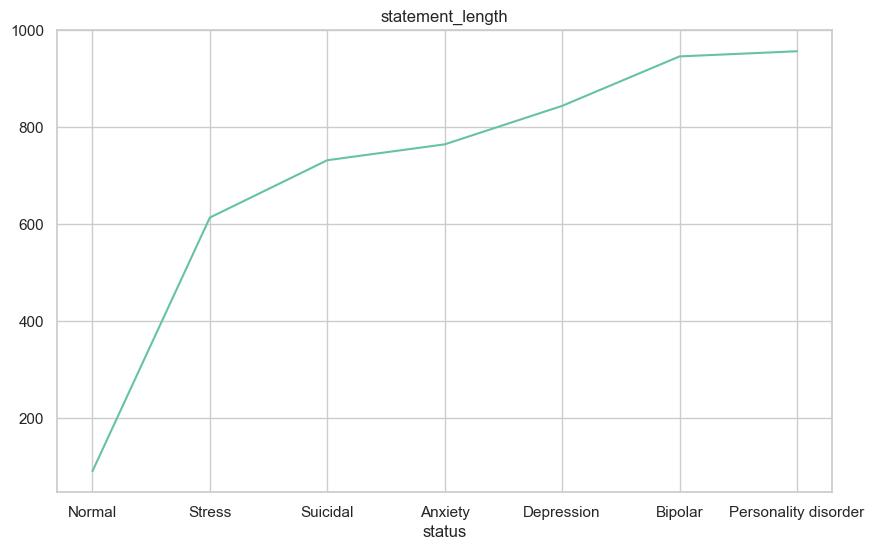

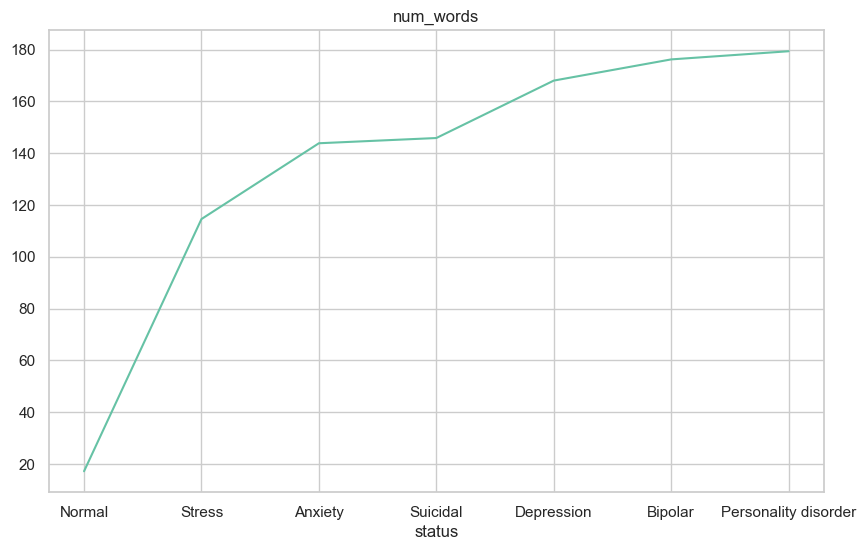

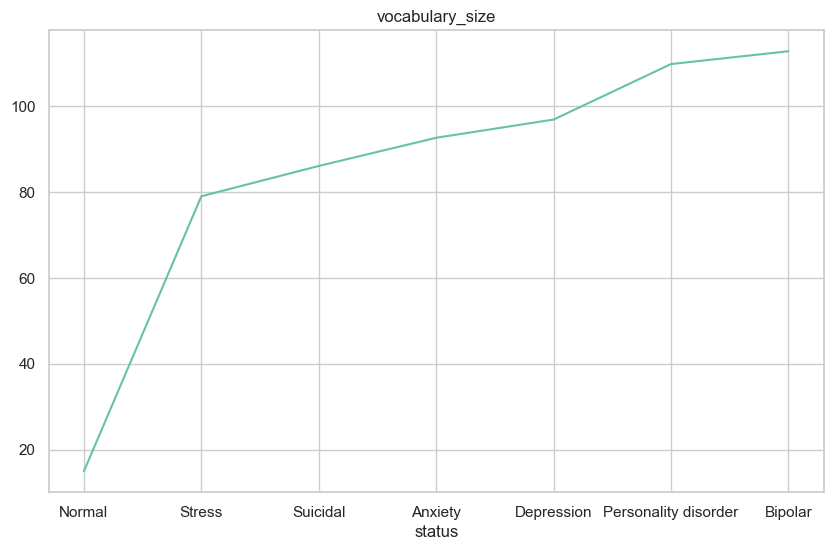

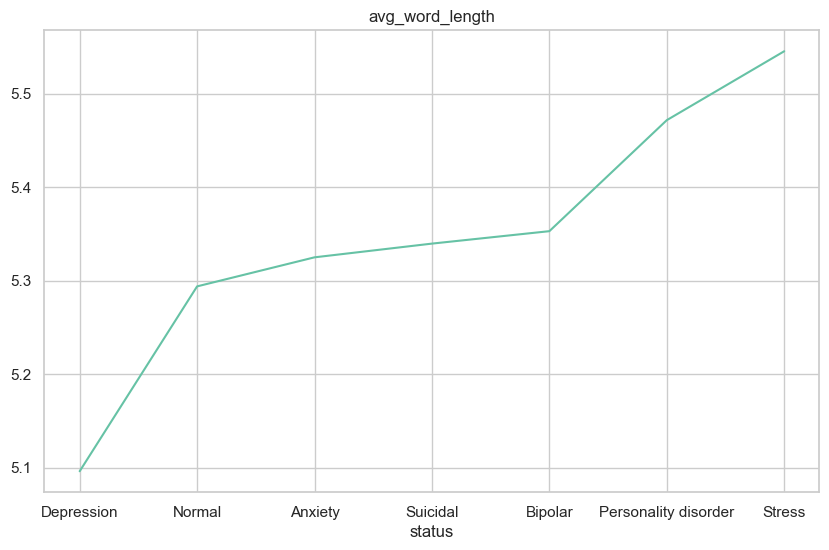

In [421]:
for feature in num_feature:
    plt.figure(figsize= (10,6))
    df.groupby('status')[feature].mean().sort_values().plot()
    plt.title(feature)
    plt.show()

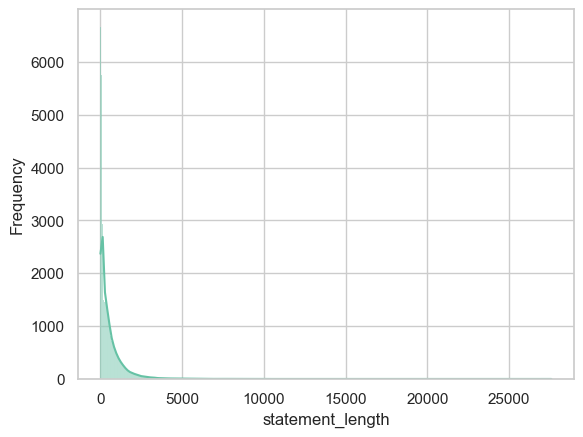

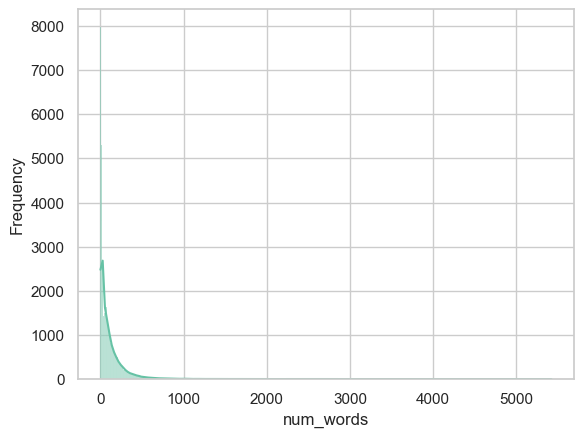

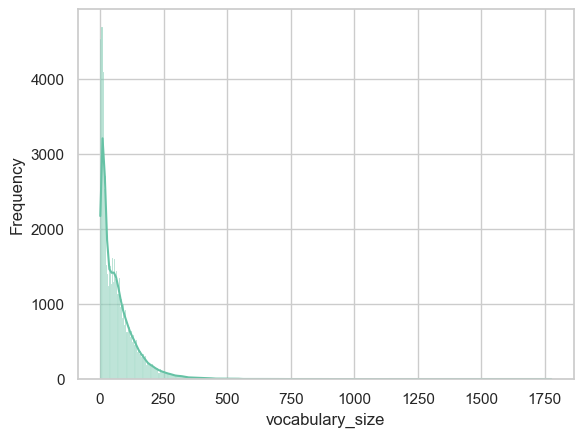

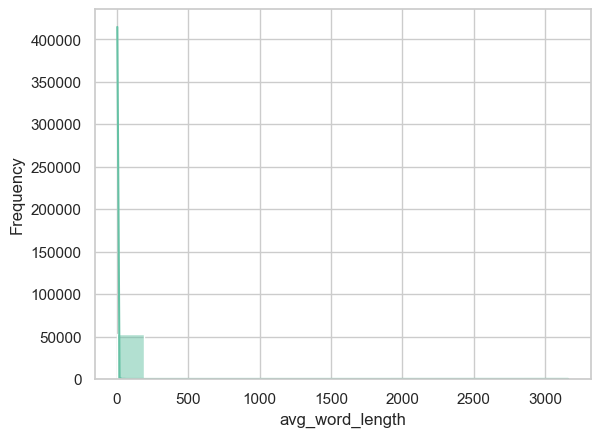

In [422]:
for feature in num_feature:
    sns.histplot(data = df, x=feature,kde=True)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [423]:
for i in num_feature:
    print(f"kurotics value for {i} is {df[i].kurt()}")
    print(f"skewness value for i is {df[i].skew()}")

kurotics value for statement_length is 98.91866137300768
skewness value for i is 5.852593648568892
kurotics value for num_words is 84.84718337235238
skewness value for i is 5.433279440882941
kurotics value for vocabulary_size is 17.417776509954393
skewness value for i is 2.6569545417908618
kurotics value for avg_word_length is 51007.60030596843
skewness value for i is 224.2048936192002


In [424]:
# here we can oberve that data is highly left skewed so if we are gonna use these feature that we have to use log tranformation 

In [425]:
# lets now same analysis while doing removing the stopwords so that we can undertand how much the std is affected

In [426]:
# here we are not gonna remove the negotion words from the text because they play a important  role in sentiment analysis


## Preprocessing for ML models


In [427]:
import re
import string
import nltk
import emoji
from nltk.corpus import stopwords

# nltk.download('stopwords')

# ---- stopwords (keep negations) ----
stop_words = set(stopwords.words('english'))
negations = {"no", "not", "nor", "n't", "never"}
stop_words = stop_words - negations


def preprocess_text(text):
    # 1. Handle missing
    if not isinstance(text, str):
        return ""

    # 2. Lowercase
    text = text.lower()

    # 3. Convert emojis → text
    text = emoji.demojize(text, delimiters=(" ", " "))
    # 😊 → smiling_face

    # 4. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 5. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 6. Expand common contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'t", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # 7. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 8. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 9. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 10. Tokenize
    words = text.split()

    # 11. Remove stopwords (keep negations)
    words = [word for word in words if word not in stop_words]

    # 12. Join back
    text = " ".join(words)

    return text

In [428]:
df["clean_text"] = df["statement"].apply(preprocess_text)

In [429]:
df.head()

,statement,status,statement_length,num_words,vocabulary_size,avg_word_length,clean_text
0,oh my gosh,Anxiety,10,3,3,3,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10,6,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,13,6,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,61,11,11,6,shifted focus something else still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,14,5,restless restless month boy mean


In [430]:
cleandf = df[["clean_text","status"]].copy()

In [431]:
cleandf.reset_index(drop=True)

,clean_text,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,shifted focus something else still worried,Anxiety
4,restless restless month boy mean,Anxiety
...,...,...
52675,nobody takes seriously i’ve dealt depressionan...,Anxiety
52676,selfishness not feel good like not belong worl...,Anxiety
52677,way sleep better ca not sleep nights meds not ...,Anxiety
52678,public speaking tips hi give presentation work...,Anxiety


In [432]:
#lets do the same statiscal analysis
cleandf["statement_length"] = cleandf["clean_text"].apply(len)

In [433]:
cleandf["num_words"] = cleandf["clean_text"].apply(lambda y :len(y.split()))

In [434]:
cleandf["vocabulary_size"] = cleandf["clean_text"].apply(lambda y: len(set(y.split())))

In [435]:
#here is tha data where statment become null while doing preprcossing 
d = cleandf[cleandf["statement_length"]==0]
d

,clean_text,status,statement_length,num_words,vocabulary_size
743,,Normal,0,0,0
1224,,Normal,0,0,0
1868,,Normal,0,0,0
2350,,Normal,0,0,0
2602,,Normal,0,0,0
...,...,...,...,...,...
33858,,Normal,0,0,0
33881,,Normal,0,0,0
33894,,Normal,0,0,0
36194,,Suicidal,0,0,0


In [436]:
df.loc[33858,["clean_text","statement","status"]]

clean_text                        
statement     what were you doing?
status                      Normal
Name: 33858, dtype: object

here we can observe that ther is some data loss while use stop words removal 

In [437]:
# counts of the categories whose statement become zer while doing preprocessing
d.groupby("status")["clean_text"].count()

status
Depression      1
Normal        130
Suicidal        4
Name: clean_text, dtype: int64

In [438]:
# lets drop the zero length text
cleandf.drop(d.index, inplace=True)

In [439]:
# lets calculate the aveage word length
cleandf['avg_word_length'] = np.round(cleandf['statement_length'] / cleandf['num_words'])
cleandf['avg_word_length'] = cleandf['avg_word_length'].map(int)

## Comparison of both data(after removing stops words and other steps)

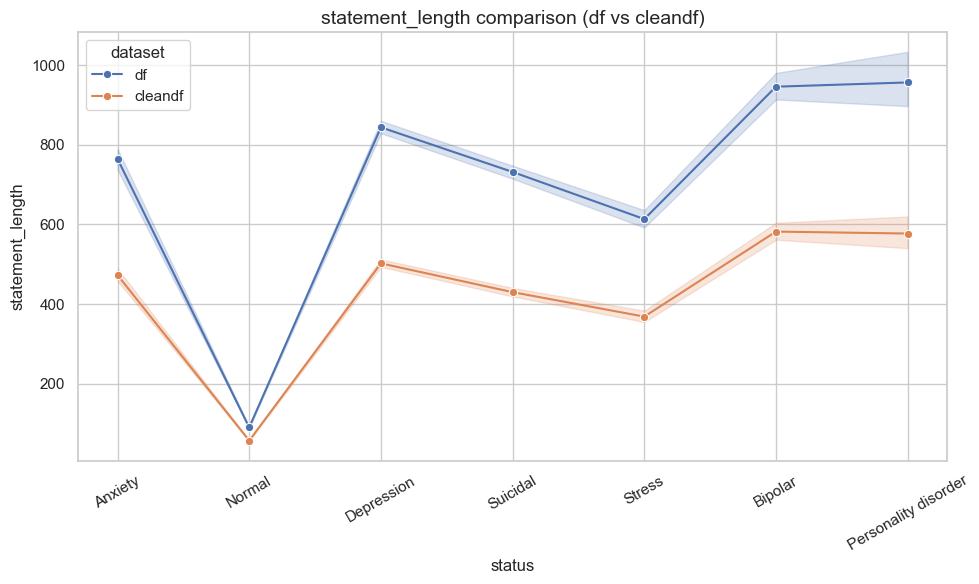

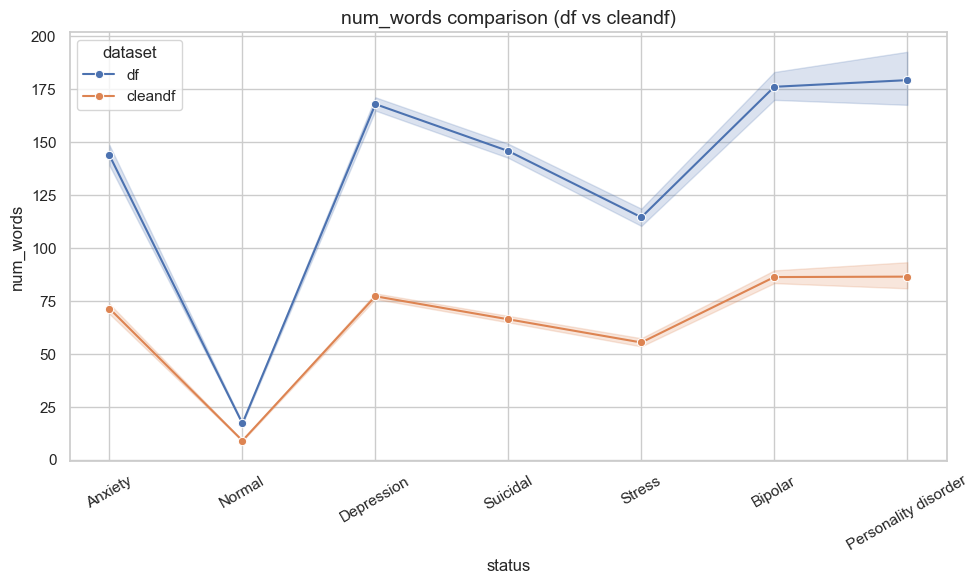

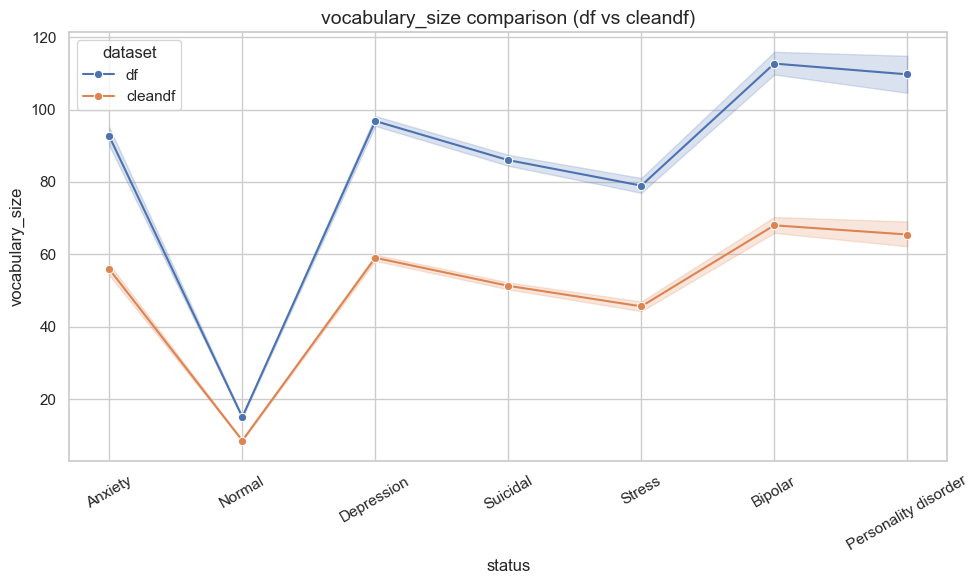

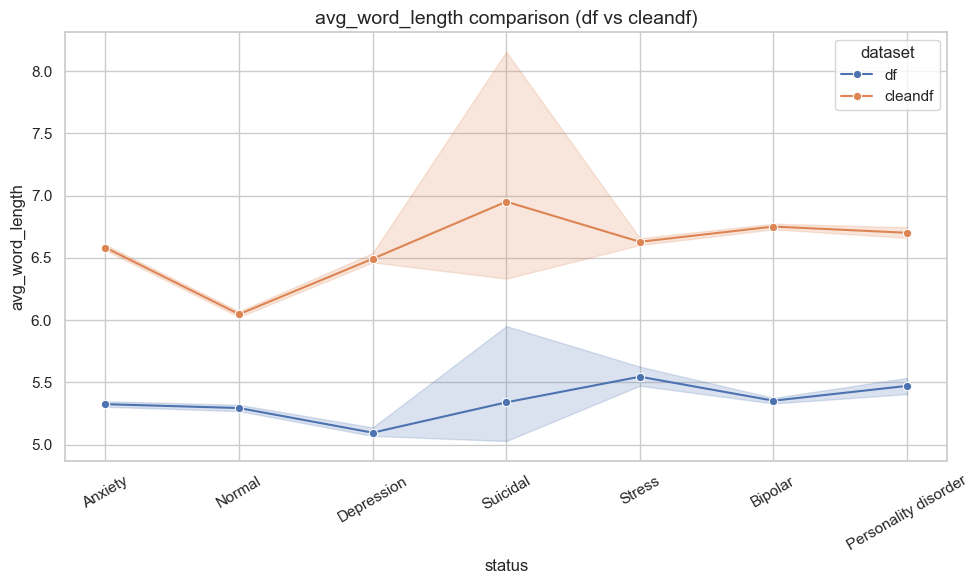

In [440]:
# lets merge both datset for makeing a better comparion visual
df_plot = df.copy()
df_plot["dataset"] = "df"

clean_plot = cleandf.copy()
clean_plot["dataset"] = "cleandf"



combined = pd.concat([df_plot, clean_plot])


# lets plot 
sns.set(style="whitegrid")

for feature in num_feature:
    plt.figure(figsize=(10,6))
    
    sns.lineplot(
        data=combined,
        x="status",
        y=feature,
        hue="dataset",
        estimator="mean",
        marker="o"
    )
    
    plt.title(f"{feature} comparison (df vs cleandf)", fontsize=14)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

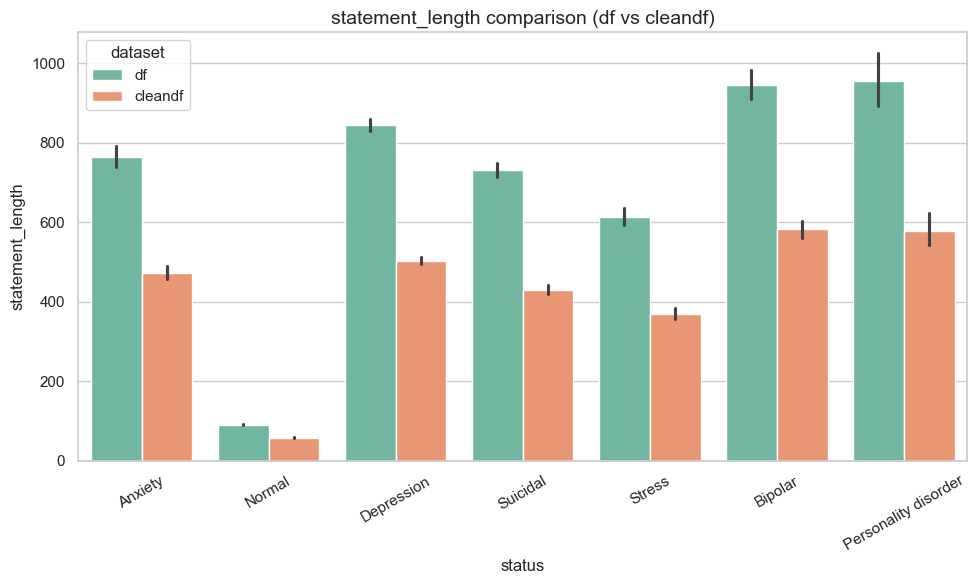

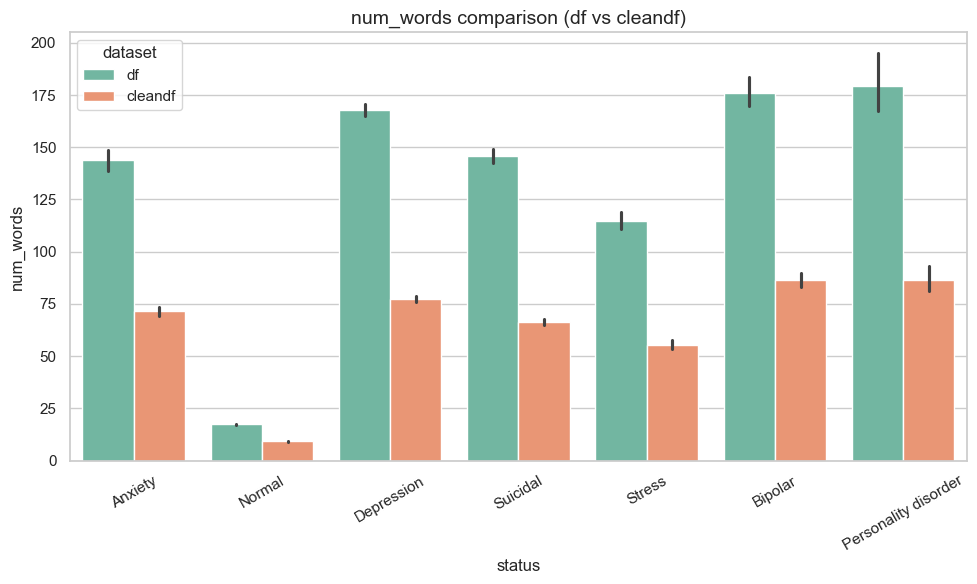

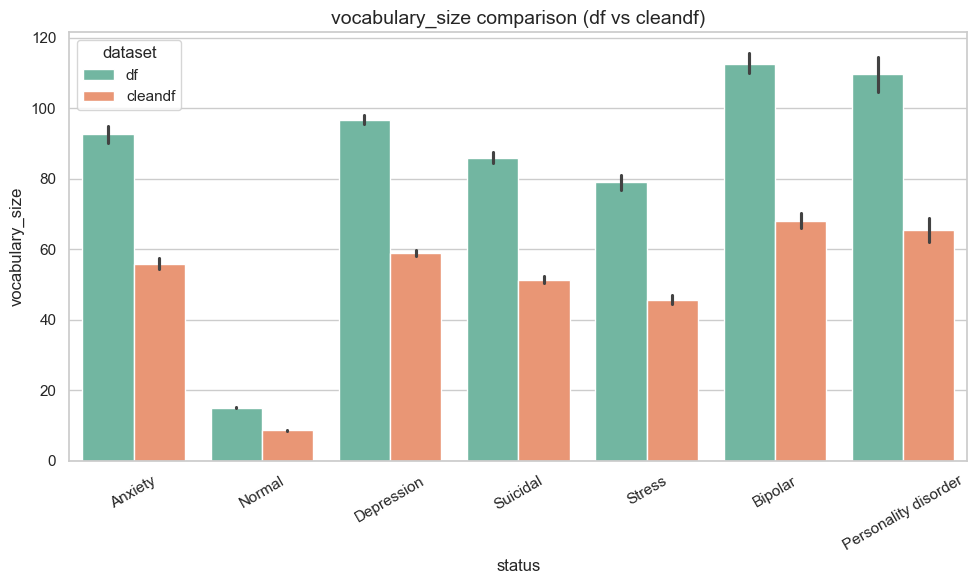

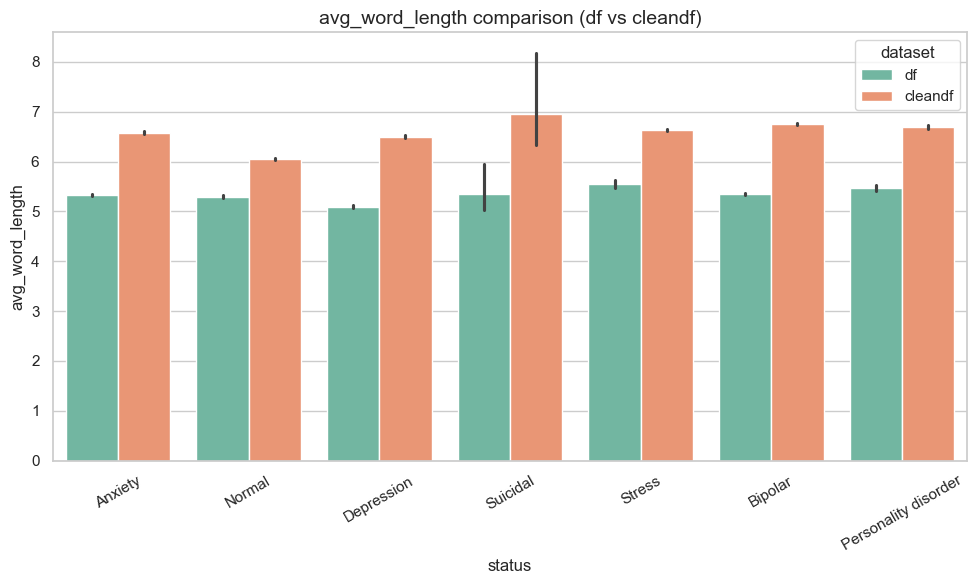

In [441]:
sns.set_theme(style="whitegrid", palette="Set2")

for feature in num_feature:
    plt.figure(figsize=(10,6))
    
    sns.barplot(
        data=combined,
        x="status",
        y=feature,
        hue="dataset",
        estimator="mean"
    )
    
    plt.title(f"{feature} comparison (df vs cleandf)", fontsize=14)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [442]:
# visually both show same distribtuion means we can consider the following points 
# -->there should be less affect on the model performace (while ml models must have to work better while removing teh stops wordsas unwanted words 
# are removed while the distribtuion remain same)

In [443]:
x = cleandf.groupby("status")[['statement_length', 'num_words', 'vocabulary_size', 'avg_word_length']].agg(["mean","median","std"]).reset_index()
y = df.groupby("status")[['statement_length', 'num_words', 'vocabulary_size', 'avg_word_length']].agg(["mean","median","std"]).reset_index()

In [444]:
x

status statement_length                     num_words         \
                                    mean median         std       mean median   
0               Anxiety       472.866181  341.0  497.213922  71.487894   52.0   
1               Bipolar       582.133958  430.0  585.411594  86.360101   63.0   
2            Depression       502.330066  335.0  565.194213  77.289424   52.0   
3                Normal        57.206809   33.0   73.459718   9.098563    6.0   
4  Personality disorder       577.260910  447.0  667.717258  86.565460   66.0   
5                Stress       368.598376  274.0  351.993899  55.475068   41.0   
6              Suicidal       430.043580  265.0  583.687002  66.417582   42.0   

              vocabulary_size                   avg_word_length         \
          std            mean median        std            mean median   
0   74.292240       55.881802   43.0  51.569543        6.581880    7.0   
1   85.625214       68.021606   54.0  56.130716        6.750810    7.0   
2   86.026109       59.046160   43.0  54.851092        6.492307    6.0   
3   10.870689        8.532104    5.0   9.570709        6.047123    6.0   
4  101.573287       65.480966   53.0  55.085443        6.701021    7.0   
5   51.953394       45.625048   37.0  35.358830        6.628527    7.0   
6   80.745354       51.301399   35.0  52.410986        6.950784    6.0   

              
         std  
0   0.718523  
1   0.614299  
2   2.442188  
3   1.526919  
4   0.689626  
5   0.691908  
6  61.239443

In [445]:
y

status statement_length                       num_words  \
                                    mean median          std        mean   
0               Anxiety       764.681073  544.0   812.378061  143.837022   
1               Bipolar       946.074901  699.0   952.510895  176.200216   
2            Depression       844.014996  562.0   953.016303  168.018177   
3                Normal        90.235942   50.0   120.899736   17.244692   
4  Personality disorder       956.731662  736.0  1149.828710  179.346332   
5                Stress       613.545419  459.0   570.071569  114.585234   
6              Suicidal       731.913905  453.0   931.976663  145.854474   

                     vocabulary_size                   avg_word_length         \
  median         std            mean median        std            mean median   
0  102.0  152.625874       92.598282   76.0  78.685220        5.324915    5.0   
1  129.0  176.488767      112.727764   93.0  82.582965        5.352899    5.0   
2  113.0  188.235576       96.838484   77.0  79.933838        5.096014    5.0   
3   10.0   22.769283       15.027412    9.0  16.969733        5.293826    5.0   
4  137.0  221.891522      109.750232   95.0  83.835927        5.471681    5.0   
5   87.0  105.895609       78.997681   66.0  53.523000        5.545419    5.0   
6   92.0  177.213461       86.041405   64.0  78.130617        5.339593    5.0   

              
         std  
0   0.687027  
1   0.574481  
2   2.412784  
3   1.633974  
4   1.121100  
5   1.996654  
6  30.620305

In [446]:
# here we can clearly observe that ther is A UNIFROM diffeence in the std also



Raw data → noisy, long, redundant  
Clean data → shorter, sharper, meaningful

In [447]:
# we can now check the skewness 
for feature in num_feature:
    print(f"skewness of {feature} in raw data is {df[feature].skew()}")
    print(f"skewness of {feature} in preprocessd data is {cleandf[feature].skew()}")

skewness of statement_length in raw data is 5.852593648568892
skewness of statement_length in preprocessd data is 7.451455592844303
skewness of num_words in raw data is 5.433279440882941
skewness of num_words in preprocessd data is 5.493412822660352
skewness of vocabulary_size in raw data is 2.6569545417908618
skewness of vocabulary_size in preprocessd data is 3.185274310337192
skewness of avg_word_length in raw data is 224.2048936192002
skewness of avg_word_length in preprocessd data is 227.71992577147012


## Log tranformation

In [448]:
# here lets do one more step of log tranfromation for normalizing the skewness 
for feature in num_feature:
    df[feature] = np.log(df[feature])
    cleandf[feature] = np.log(cleandf[feature])


In [449]:
# we can now check the skewness 
for feature in num_feature:
    print(f"skewness of {feature} in raw data is {df[feature].skew()}")
    print(f"skewness of {feature} in preprocessd data is {cleandf[feature].skew()}")

skewness of statement_length in raw data is -0.2826807181751467
skewness of statement_length in preprocessd data is -0.33685602275396753
skewness of num_words in raw data is -0.29012231775753317
skewness of num_words in preprocessd data is -0.2670212968961125
skewness of vocabulary_size in raw data is -0.43457455793578464
skewness of vocabulary_size in preprocessd data is -0.3335670297287104
skewness of avg_word_length in raw data is 4.124188530071325
skewness of avg_word_length in preprocessd data is 1.3282195573930182


In [450]:
# as we can observe that it is improved very much


## TARGET FEATURE CORELATION

In [451]:
label_ordered = df['status'].value_counts().index

label_ordered = {k:i for i,k in enumerate(label_ordered,0)}

df['status'] = df['status'].map(label_ordered)
df.head()

,statement,status,statement_length,num_words,vocabulary_size,avg_word_length,clean_text
0,oh my gosh,3,2.302585,1.098612,1.098612,1.098612,oh gosh
1,"trouble sleeping, confused mind, restless hear...",3,4.158883,2.302585,2.302585,1.791759,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",3,4.356709,2.639057,2.564949,1.791759,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,3,4.110874,2.397895,2.397895,1.791759,shifted focus something else still worried
4,"I'm restless and restless, it's been a month n...",3,4.276666,2.639057,2.639057,1.609438,restless restless month boy mean


In [452]:
print(label_ordered)

{'Normal': 0, 'Depression': 1, 'Suicidal': 2, 'Anxiety': 3, 'Bipolar': 4, 'Stress': 5, 'Personality disorder': 6}


In [453]:
corr = df.corr(numeric_only=True)
corr

,status,statement_length,num_words,vocabulary_size,avg_word_length
status,1.000000,0.478905,0.465510,0.478576,0.080192
statement_length,0.478905,1.000000,0.994730,0.991830,-0.007277
num_words,0.465510,0.994730,1.000000,0.995892,-0.103332
vocabulary_size,0.478576,0.991830,0.995892,1.000000,-0.094615
avg_word_length,0.080192,-0.007277,-0.103332,-0.094615,1.000000


In [454]:
corr["status"].sort_values(ascending=False)

status              1.000000
statement_length    0.478905
vocabulary_size     0.478576
num_words           0.465510
avg_word_length     0.080192
Name: status, dtype: float64

<Axes: >

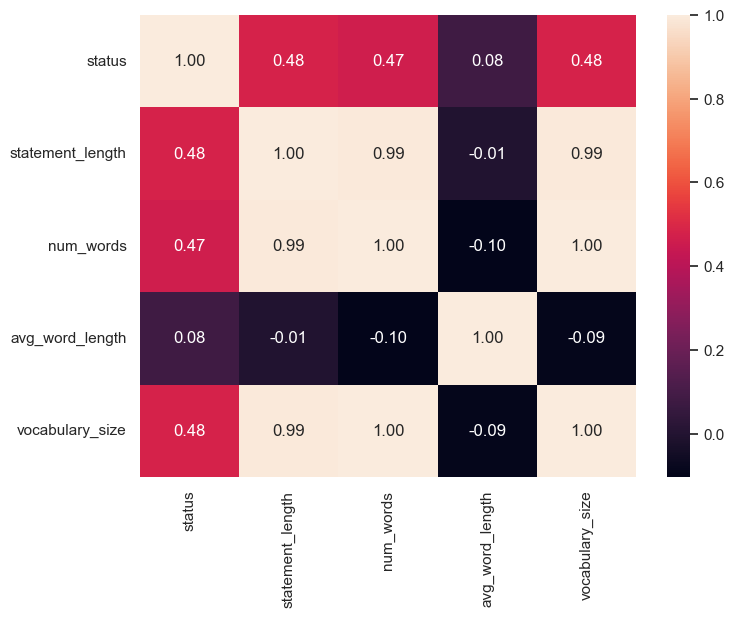

In [455]:
Heatmap = df[['status','statement_length','num_words','avg_word_length','vocabulary_size']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(Heatmap,annot=True, fmt=".2f")

In [456]:
# similarly do for cleandf
label_ordered_clean = cleandf['status'].value_counts().index

label_ordered_clean = {k:i for i,k in enumerate(label_ordered_clean,0)}

cleandf['status'] = cleandf['status'].map(label_ordered_clean)
cleandf.head()

,clean_text,status,statement_length,num_words,vocabulary_size,avg_word_length
0,oh gosh,3,1.945910,0.693147,0.693147,1.386294
1,trouble sleeping confused mind restless heart ...,3,3.912023,1.945910,1.945910,1.945910
2,wrong back dear forward doubt stay restless re...,3,4.060443,2.197225,2.079442,1.791759
3,shifted focus something else still worried,3,3.737670,1.791759,1.791759,1.945910
4,restless restless month boy mean,3,3.465736,1.609438,1.386294,1.791759


In [457]:
corr = cleandf.corr(numeric_only=True)
corr

,status,statement_length,num_words,vocabulary_size,avg_word_length
status,1.000000,0.471275,0.463398,0.463547,0.214601
statement_length,0.471275,1.000000,0.994443,0.992110,0.355067
num_words,0.463398,0.994443,1.000000,0.996618,0.259531
vocabulary_size,0.463547,0.992110,0.996618,1.000000,0.267784
avg_word_length,0.214601,0.355067,0.259531,0.267784,1.000000


In [458]:
corr["status"].sort_values(ascending=False)

status              1.000000
statement_length    0.471275
vocabulary_size     0.463547
num_words           0.463398
avg_word_length     0.214601
Name: status, dtype: float64

## Saving file 

In [459]:
df.drop(columns="clean_text",inplace=True)

In [460]:
# labelling back 
df['status'] = df['status'].map(label_ordered)

In [461]:
df.to_csv("cleandata.csv")

In [462]:
cleandf['status'] = cleandf['status'].map(label_ordered_clean)

In [463]:
cleandf.to_csv("processed_data.csv")